# ORBIS Raw Extract — Exploratory Data Analysis

Dataset: `data/ORBIS_Abzug_DE_2005_2024.csv`  
This is the **full raw ORBIS export** for German companies, 2005–2024.  
It covers all company types (listed and unlisted) with 286 columns of financial, structural, and location data.

**Key questions answered here:**
- How many and which types of companies are covered?
- How many are publicly listed?
- What does the financial data look like?
- Where are these companies located?
- How does this differ from the merged longitudinal dataset?

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# Load full dataset — 671k rows, 286 columns
df = pd.read_csv("data/ORBIS_Abzug_DE_2005_2024.csv", low_memory=False)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

CORE_FIN = ["TOAS","TURN","EMPL","SHFD","LTDB","OPPL","PL","PLBT",
            "ROE","ROA","ROCE","PRMA","GRMA","STAF","RD","CASH","CF","EBTA","GEAR","SOLR","CURR"]


Shape: 671,626 rows × 286 columns


## 1. Dataset Overview

In [46]:
print("=== STRUCTURE ===")
print(f"Rows (company × year observations): {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Unique companies (bvdid): {df['bvdid'].nunique():,}")
print(f"Unique ISINs: {df['SD_ISIN'].nunique():,}")
print(f"Year range (CLOSDATE_year): {int(df['CLOSDATE_year'].min())} – {int(df['CLOSDATE_year'].max())}")
print()

print("=== COMPANY CATEGORY ===")
print("l = large company, v = very large company")
print(df["CATEGORY_OF_COMPANY"].value_counts(dropna=False).to_string())
print()

print("=== LISTING STATUS ===")
print(df["LISTED"].value_counts(dropna=False).to_string())
print()

print("=== CONSOLIDATION CODE ===")
print("U1/U2 = unconsolidated, C1/C2 = consolidated")
print(df["CONSCODE"].value_counts(dropna=False).to_string())
print()

print("=== REPORTING UNITS ===")
print(df["ORIG_UNITS"].value_counts(dropna=False).to_string())
print()

print("=== CURRENCY ===")
print(df["ORIG_CURRENCY"].value_counts(dropna=False).to_string())


=== STRUCTURE ===
Rows (company × year observations): 671,626
Columns: 286
Unique companies (bvdid): 77,188
Unique ISINs: 1,311
Year range (CLOSDATE_year): 2005 – 2024

=== COMPANY CATEGORY ===
l = large company, v = very large company
CATEGORY_OF_COMPANY
l    482446
v    189180

=== LISTING STATUS ===
LISTED
Unlisted    638522
Listed       20574
Delisted     12530

=== CONSOLIDATION CODE ===
U1/U2 = unconsolidated, C1/C2 = consolidated
CONSCODE
U1    501710
U2     86391
C2     73881
C1      9612
LF        32

=== REPORTING UNITS ===
ORIG_UNITS
thousands    624699
units         40259
millions       6573
billions         95

=== CURRENCY ===
ORIG_CURRENCY
EUR    670316
GBP      1278
USD        30
SEK         2


## 2. Public Companies — Listed & Delisted

In [47]:
listed = df[df["LISTED"].isin(["Listed","Delisted"])].copy()
cur_listed = df[df["LISTED"] == "Listed"].copy()

print(f"Listed + Delisted rows:     {len(listed):,}")
print(f"Unique listed+delisted cos: {listed['bvdid'].nunique():,}")
print(f"Currently listed companies: {cur_listed['bvdid'].nunique():,}")
print(f"Delisted companies:         {df[df['LISTED']=='Delisted']['bvdid'].nunique():,}")
print()

print("=== MAIN EXCHANGE (listed+delisted) ===")
comp_l = listed.drop_duplicates("bvdid")
print(comp_l["MAINEXCH"].value_counts(dropna=False).head(20).to_string())
print()

print("=== LEGAL FORM (currently listed) ===")
comp_cur = cur_listed.drop_duplicates("bvdid")
print(comp_cur["LEGALFRM"].value_counts(dropna=False).head(12).to_string())


Listed + Delisted rows:     33,104
Unique listed+delisted cos: 1,316
Currently listed companies: 655
Delisted companies:         661

=== MAIN EXCHANGE (listed+delisted) ===
MAINEXCH
Delisted                          661
Boerse Frankfurt                  407
Boerse Duesseldorf                 59
Boerse Munchen                     51
Boerse Berlin                      44
Boerse Hamburg                     42
Boerse Stuttgart                   19
OTC Bulletin Board                 10
NASDAQ National Market              7
Wiener Boerse                       4
XETRA Stock Exchange                3
Euronext Paris                      3
New York Stock Exchange (NYSE)      2
Euronext Amsterdam                  2
OTC Pink Market                     1
Oslo Bors                           1

=== LEGAL FORM (currently listed) ===
LEGALFRM
Public limited company - AG                                            477
European company - SE                                                  116
Joint stock

## 3. Panel Coverage Over Time

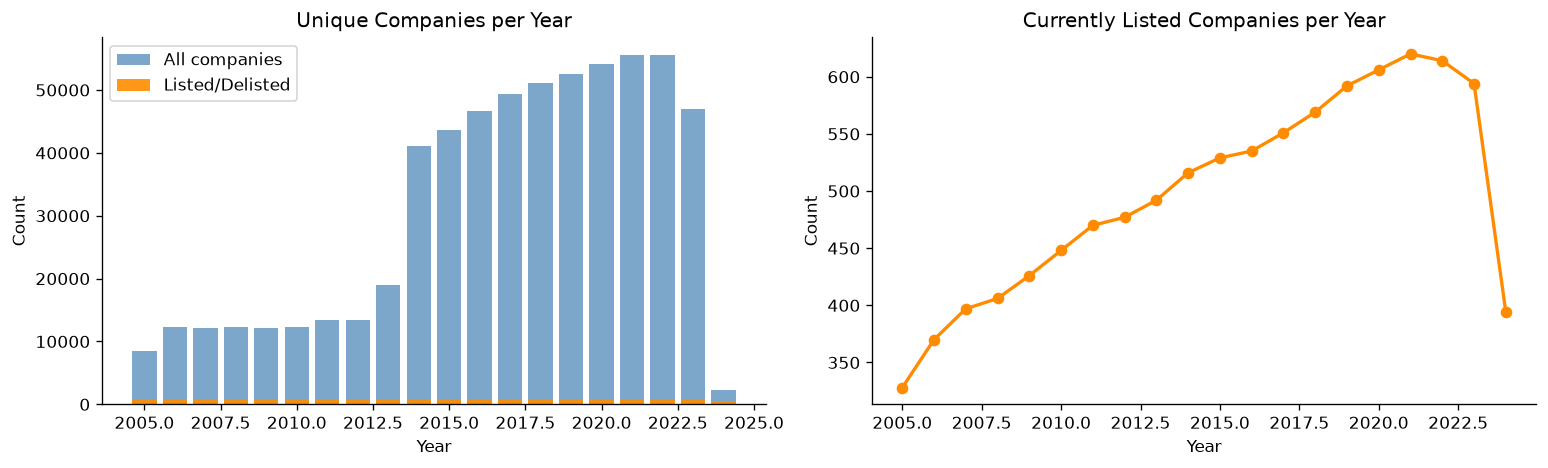

Note: the large total (77k companies) includes subsidiaries, holding co's, and foreign-controlled entities
Only ~655 are currently listed on a German exchange (mostly Frankfurt/XETRA)


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# All companies per year
all_per_year = df.groupby("CLOSDATE_year")["bvdid"].nunique()
listed_per_year = listed.groupby("CLOSDATE_year")["bvdid"].nunique()

axes[0].bar(all_per_year.index, all_per_year.values, color="steelblue", alpha=0.7, label="All companies")
axes[0].bar(listed_per_year.index, listed_per_year.values, color="darkorange", alpha=0.9, label="Listed/Delisted")
axes[0].set_title("Unique Companies per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].legend()

# Listing status over time (currently listed)
cl_per_year = cur_listed.groupby("CLOSDATE_year")["bvdid"].nunique()
axes[1].plot(cl_per_year.index, cl_per_year.values, marker="o", color="darkorange", linewidth=2)
axes[1].set_title("Currently Listed Companies per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Note: the large total (77k companies) includes subsidiaries, holding co's, and foreign-controlled entities")
print("Only ~655 are currently listed on a German exchange (mostly Frankfurt/XETRA)")


## 4. Financial Variable Coverage

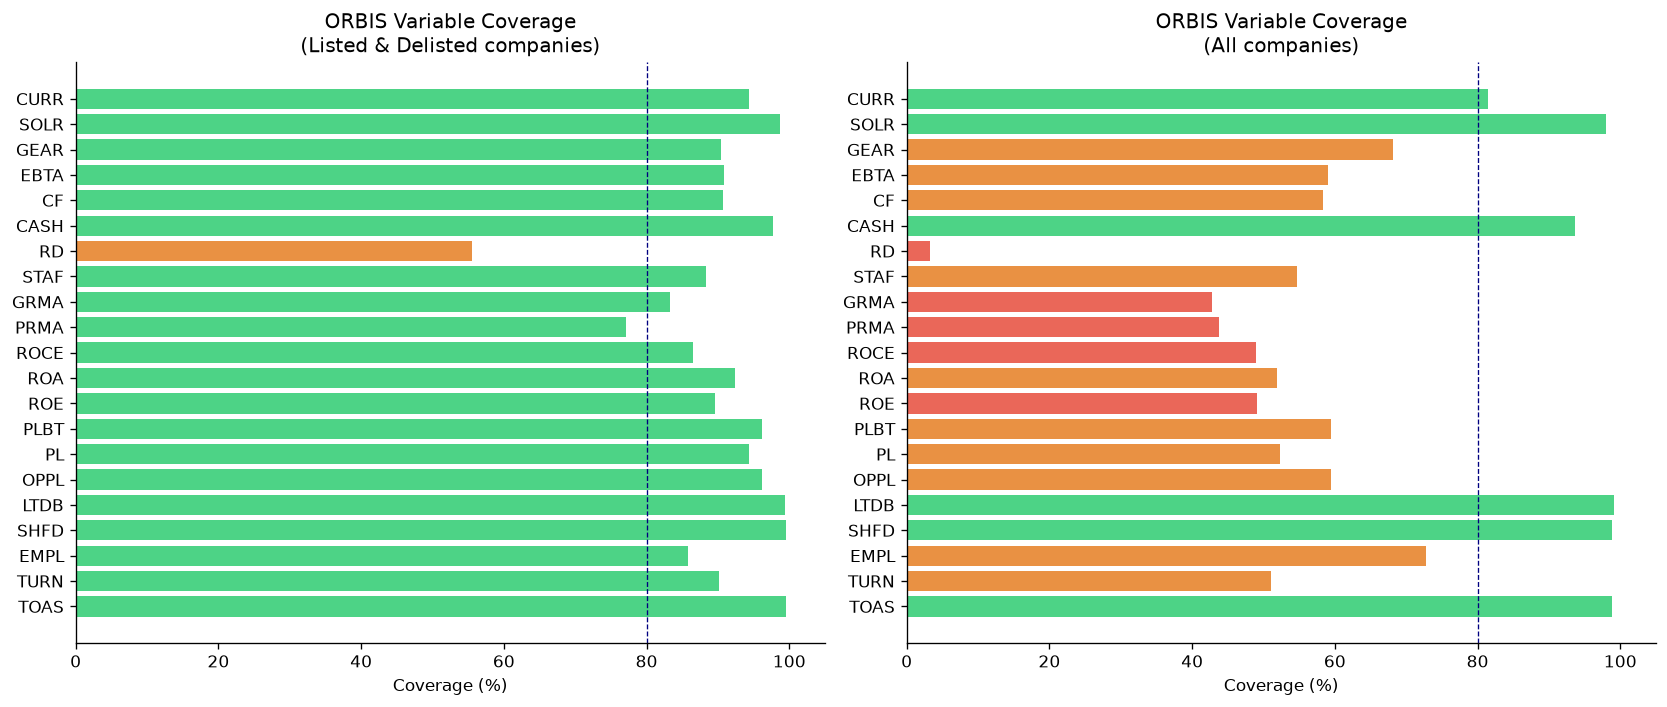

Coverage (listed+delisted):
  TOAS: 100%
  TURN: 90%
  EMPL: 86%
  SHFD: 100%
  LTDB: 99%
  OPPL: 96%
  PL: 94%
  PLBT: 96%
  ROE: 90%
  ROA: 92%
  ROCE: 86%
  PRMA: 77%
  GRMA: 83%
  STAF: 88%
  RD: 55%
  CASH: 98%
  CF: 91%
  EBTA: 91%
  GEAR: 90%
  SOLR: 99%
  CURR: 94%


In [49]:
# Coverage for listed+delisted companies
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, subset, title in [
    (axes[0], listed, "Listed & Delisted companies"),
    (axes[1], df, "All companies")
]:
    cov = pd.Series({c: subset[c].notna().mean()*100 for c in CORE_FIN if c in subset.columns})
    colors = ["#2ecc71" if v >= 75 else "#e67e22" if v >= 50 else "#e74c3c" for v in cov.values]
    ax.barh(cov.index, cov.values, color=colors, alpha=0.85)
    ax.axvline(80, color="navy", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Coverage (%)")
    ax.set_title(f"ORBIS Variable Coverage\n({title})")
    ax.set_xlim(0, 105)

plt.tight_layout()
plt.show()

print("Coverage (listed+delisted):")
for c in CORE_FIN:
    if c in listed.columns:
        n = listed[c].notna().sum()
        print(f"  {c}: {100*n/len(listed):.0f}%")


## 5. Unit Normalization

**Important:** Raw ORBIS values use different units across companies.  
Always normalize before comparing financials across companies.

| ORIG_UNITS | Multiplier |
|---|---|
| `thousands` | × 1,000 |
| `millions` | × 1,000,000 |
| `billions` | × 1,000,000,000 |
| `units` | × 1 |

In [50]:
UNIT_MAP = {"thousands": 1e3, "millions": 1e6, "billions": 1e9, "units": 1.0}

def normalize_col(df_in, col):
    """Multiply col by ORIG_UNITS multiplier to get actual EUR values."""
    mult = df_in["ORIG_UNITS"].map(UNIT_MAP).fillna(1e3)
    return df_in[col] * mult

# Apply to currently listed, latest year per company
comp = cur_listed.sort_values("CLOSDATE_year").groupby("bvdid").last().reset_index()

for col in ["TOAS","TURN","STAF","CASH"]:
    comp[f"{col}_eur"] = normalize_col(comp, col)

print(f"Currently listed companies (latest year): {len(comp)}")
print()
print("After normalization to EUR:")
for col, label in [("TOAS_eur","Total Assets"), ("TURN_eur","Revenue"), ("STAF_eur","Staff Costs"), ("CASH_eur","Cash")]:
    s = comp[col].dropna()
    print(f"  {label}: median={s.median()/1e9:.1f}B  mean={s.mean()/1e9:.1f}B  max={s.max()/1e9:.1f}B  (EUR)")


Currently listed companies (latest year): 655

After normalization to EUR:
  Total Assets: median=117.8B  mean=1104938.2B  max=230751743.2B  (EUR)
  Revenue: median=65.7B  mean=476673.0B  max=109413782.9B  (EUR)
  Staff Costs: median=16.0B  mean=123442.2B  max=34445619.0B  (EUR)
  Cash: median=10.9B  mean=127510.8B  max=52822535.5B  (EUR)


## 6. Company Size Distribution (Currently Listed)

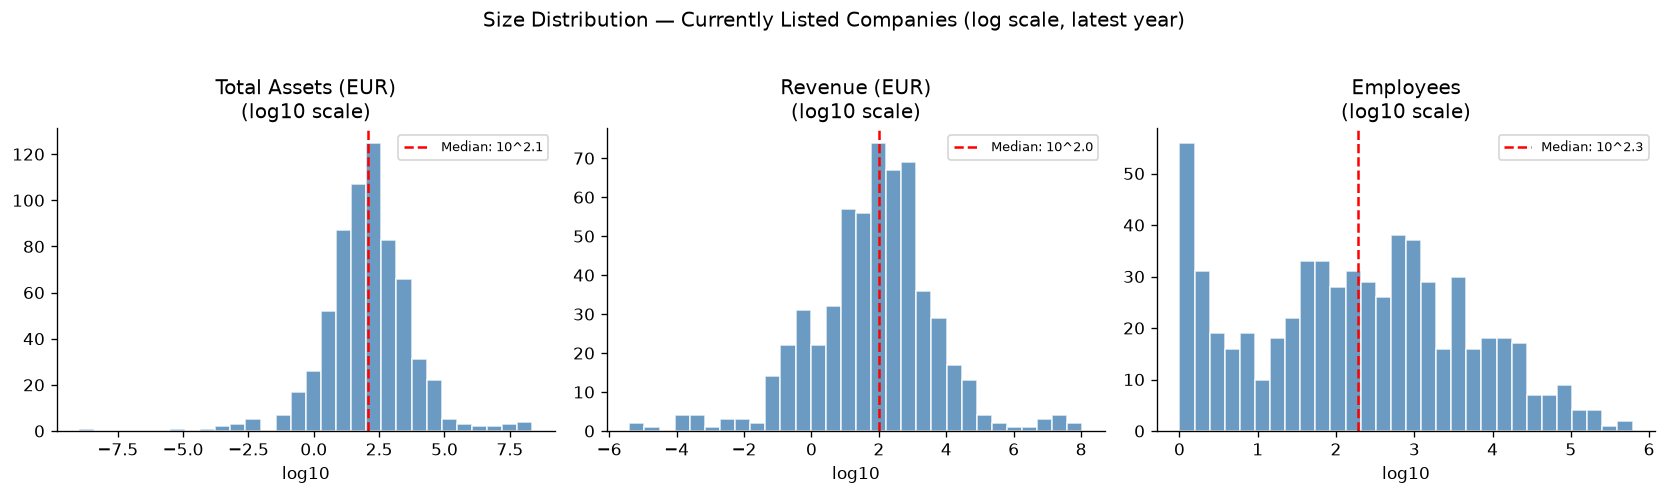

Revenue size buckets (currently listed companies):
size_class
<10M         17
10M-100M     12
100M-1B      60
1B-10B       72
>10B        367
NaN         127


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in [
    (axes[0], "TOAS_eur", "Total Assets (EUR)"),
    (axes[1], "TURN_eur", "Revenue (EUR)"),
    (axes[2], "EMPL", "Employees")
]:
    if col == "EMPL":
        data = comp[col].dropna()
    else:
        data = comp[col].dropna() / 1e9
    # Log scale due to extreme skew
    data_log = np.log10(data[data > 0])
    ax.hist(data_log, bins=30, color="steelblue", alpha=0.8, edgecolor="white")
    ax.axvline(data_log.median(), color="red", linestyle="--", linewidth=1.5,
               label=f"Median: 10^{data_log.median():.1f}")
    ax.set_title(f"{label}\n(log10 scale)")
    ax.set_xlabel("log10")
    ax.legend(fontsize=8)

plt.suptitle("Size Distribution — Currently Listed Companies (log scale, latest year)", y=1.02)
plt.tight_layout()
plt.show()

# Size buckets
comp["size_class"] = pd.cut(
    comp["TURN_eur"].fillna(0),
    bins=[0, 1e7, 1e8, 1e9, 1e10, 1e13],
    labels=["<10M","10M-100M","100M-1B","1B-10B",">10B"]
)
print("Revenue size buckets (currently listed companies):")
print(comp["size_class"].value_counts(dropna=False).sort_index().to_string())


## 7. Profitability — Listed vs All

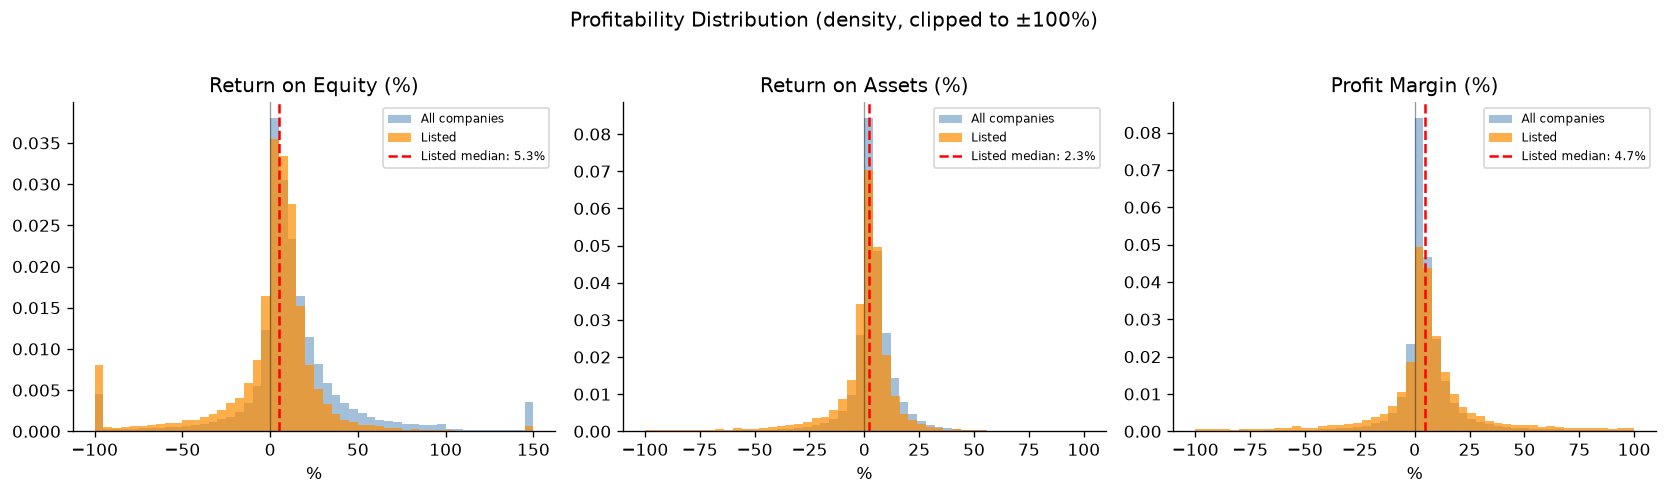

Median profitability (listed+delisted):
  ROE: 5.3%
  ROA: 2.3%
  ROCE: 5.3%
  PRMA: 4.7%


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in [
    (axes[0], "ROE",  "Return on Equity (%)"),
    (axes[1], "ROA",  "Return on Assets (%)"),
    (axes[2], "PRMA", "Profit Margin (%)")
]:
    data_all = df[col].dropna().clip(-100, 150)
    data_list = listed[col].dropna().clip(-100, 150)

    ax.hist(data_all, bins=50, color="steelblue", alpha=0.5, density=True, label="All companies")
    ax.hist(data_list, bins=50, color="darkorange", alpha=0.7, density=True, label="Listed")
    ax.axvline(data_list.median(), color="red", linestyle="--", linewidth=1.5,
               label=f"Listed median: {data_list.median():.1f}%")
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.4)
    ax.set_title(label)
    ax.set_xlabel("%")
    ax.legend(fontsize=7)

plt.suptitle("Profitability Distribution (density, clipped to ±100%)", y=1.02)
plt.tight_layout()
plt.show()

print("Median profitability (listed+delisted):")
for c in ["ROE","ROA","ROCE","PRMA"]:
    print(f"  {c}: {listed[c].median():.1f}%")


## 8. Top Public Companies by Revenue

In [53]:
UNIT_MAP = {"thousands": 1e3, "millions": 1e6, "billions": 1e9, "units": 1.0}
comp["TURN_eur"] = comp["TURN"] * comp["ORIG_UNITS"].map(UNIT_MAP).fillna(1e3)

print("=== TOP 20 CURRENTLY LISTED COMPANIES BY REVENUE ===")
top = comp.sort_values("TURN_eur", ascending=False)[
    ["NAME_INTERNAT","CLOSDATE_year","TURN_eur","EMPL","MAINEXCH","LEGALFRM"]
].head(20).copy()
top["TURN_eur"] = (top["TURN_eur"] / 1e9).round(1)
top["EMPL"] = top["EMPL"].apply(lambda x: f"{int(x):,}" if pd.notna(x) else "N/A")
top.columns = ["Company","Last Year","Revenue (Bn EUR)","Employees","Exchange","Legal Form"]
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.max_rows", 30)
print(top.to_string(index=False))


=== TOP 20 CURRENTLY LISTED COMPANIES BY REVENUE ===
                                    Company  Last Year  Revenue (Bn EUR) Employees             Exchange                           Legal Form
Bayerische Motoren Werke Aktiengesellschaft       2024       109413782.9    86,895 XETRA Stock Exchange          Public limited company - AG
                 Siemens Aktiengesellschaft       2024        85011241.4   324,000     Boerse Frankfurt          Public limited company - AG
                    Fresenius SE & Co. KGaA       2024        22682293.7   176,341     Boerse Frankfurt                European company - SE
     MERCK Kommanditgesellschaft auf Aktien       2024        21978958.7    62,329     Boerse Frankfurt Limited partnership by shares - KGaA
                  Fresenius Medical Care AG       2024        20088067.0   113,840     Boerse Frankfurt          Public limited company - AG
                                Covestro AG       2024        14730556.6    17,522     Boerse Frankfu

## 9. Regional Distribution

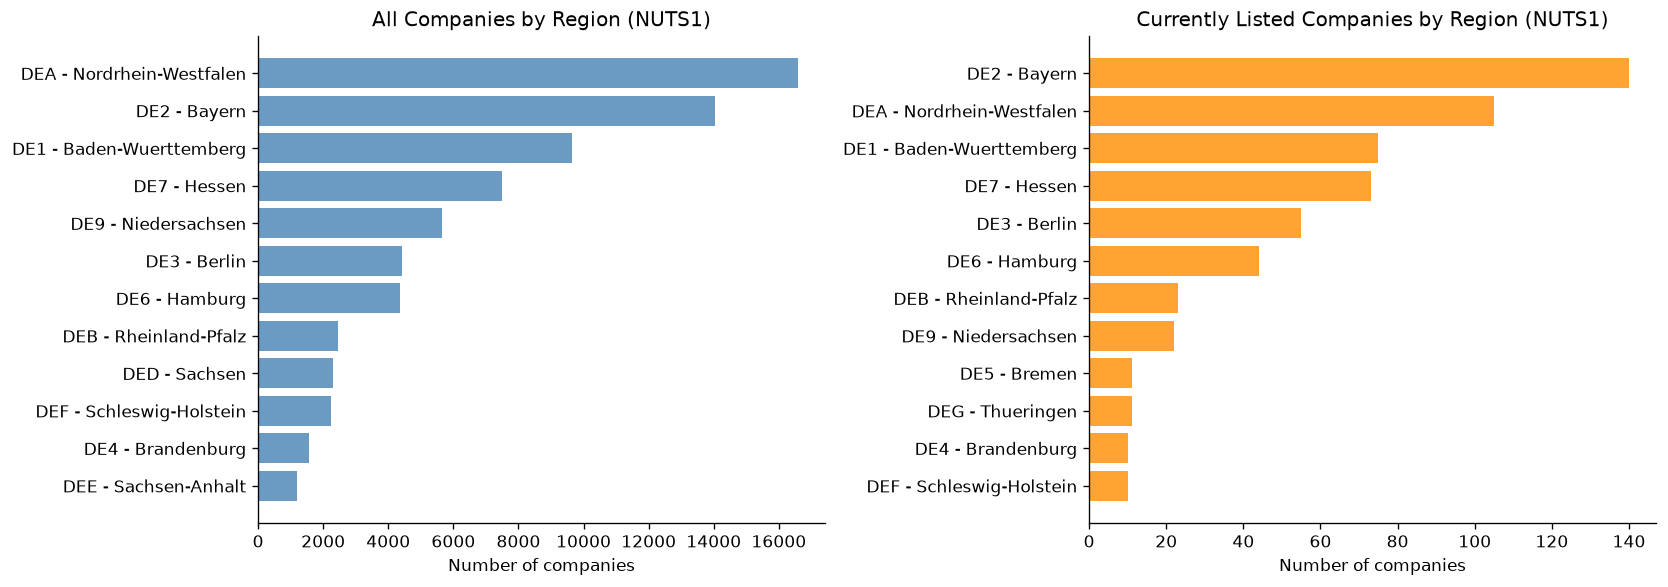

Companies with no NUTS1 (all): 1621
Companies with no NUTS1 (listed): 63

Top 10 cities (currently listed):
CITY_NATIVE
München       67
Berlin        62
Hamburg       49
Frankfurt     48
Düsseldorf    30
Köln          21
Augsburg      13
Essen         10
Stuttgart     10
Heidelberg     9


In [54]:
comp_all = df.drop_duplicates("bvdid")
comp_listed_snap = cur_listed.drop_duplicates("bvdid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All companies
regions_all = comp_all["NUTS1"].value_counts(dropna=True).head(12)
axes[0].barh(regions_all.index, regions_all.values, color="steelblue", alpha=0.8)
axes[0].set_title("All Companies by Region (NUTS1)")
axes[0].set_xlabel("Number of companies")
axes[0].invert_yaxis()

# Listed companies
regions_listed = comp_listed_snap["NUTS1"].value_counts(dropna=True).head(12)
axes[1].barh(regions_listed.index, regions_listed.values, color="darkorange", alpha=0.8)
axes[1].set_title("Currently Listed Companies by Region (NUTS1)")
axes[1].set_xlabel("Number of companies")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Companies with no NUTS1 (all): {comp_all['NUTS1'].isna().sum()}")
print(f"Companies with no NUTS1 (listed): {comp_listed_snap['NUTS1'].isna().sum()}")
print()
print("Top 10 cities (currently listed):")
print(comp_listed_snap["CITY_NATIVE"].value_counts(dropna=True).head(10).to_string())


## 10. R&D Spending (Public Companies)

Listed companies with R&D data: 180 / 655



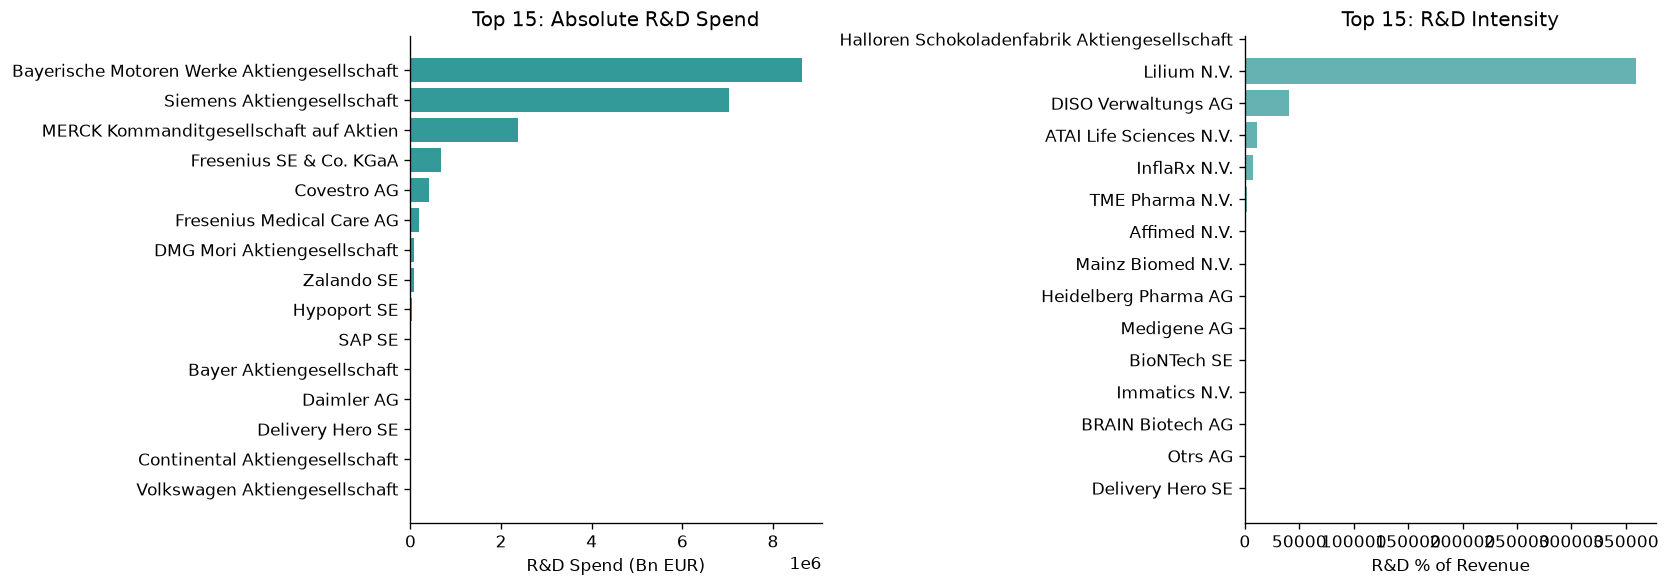

In [55]:
UNIT_MAP = {"thousands": 1e3, "millions": 1e6, "billions": 1e9, "units": 1.0}
comp["RD_eur"]   = comp["RD"]   * comp["ORIG_UNITS"].map(UNIT_MAP).fillna(1e3)

rd = comp[comp["RD_eur"].notna() & (comp["RD_eur"] > 0)].copy()
rd["RD_pct"] = 100 * rd["RD"] / rd["TURN"]  # same units, safe ratio
rd = rd.sort_values("RD_eur", ascending=False)

print(f"Listed companies with R&D data: {len(rd)} / {len(comp)}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top15 = rd.head(15)
axes[0].barh(top15["NAME_INTERNAT"].fillna(top15["bvdid"]), top15["RD_eur"]/1e9, color="teal", alpha=0.8)
axes[0].set_xlabel("R&D Spend (Bn EUR)")
axes[0].set_title("Top 15: Absolute R&D Spend")
axes[0].invert_yaxis()

top15_pct = rd.sort_values("RD_pct", ascending=False).head(15)
axes[1].barh(top15_pct["NAME_INTERNAT"].fillna(top15_pct["bvdid"]), top15_pct["RD_pct"], color="teal", alpha=0.6)
axes[1].set_xlabel("R&D % of Revenue")
axes[1].set_title("Top 15: R&D Intensity")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 11. Financial Trends Over Time (Listed Companies)

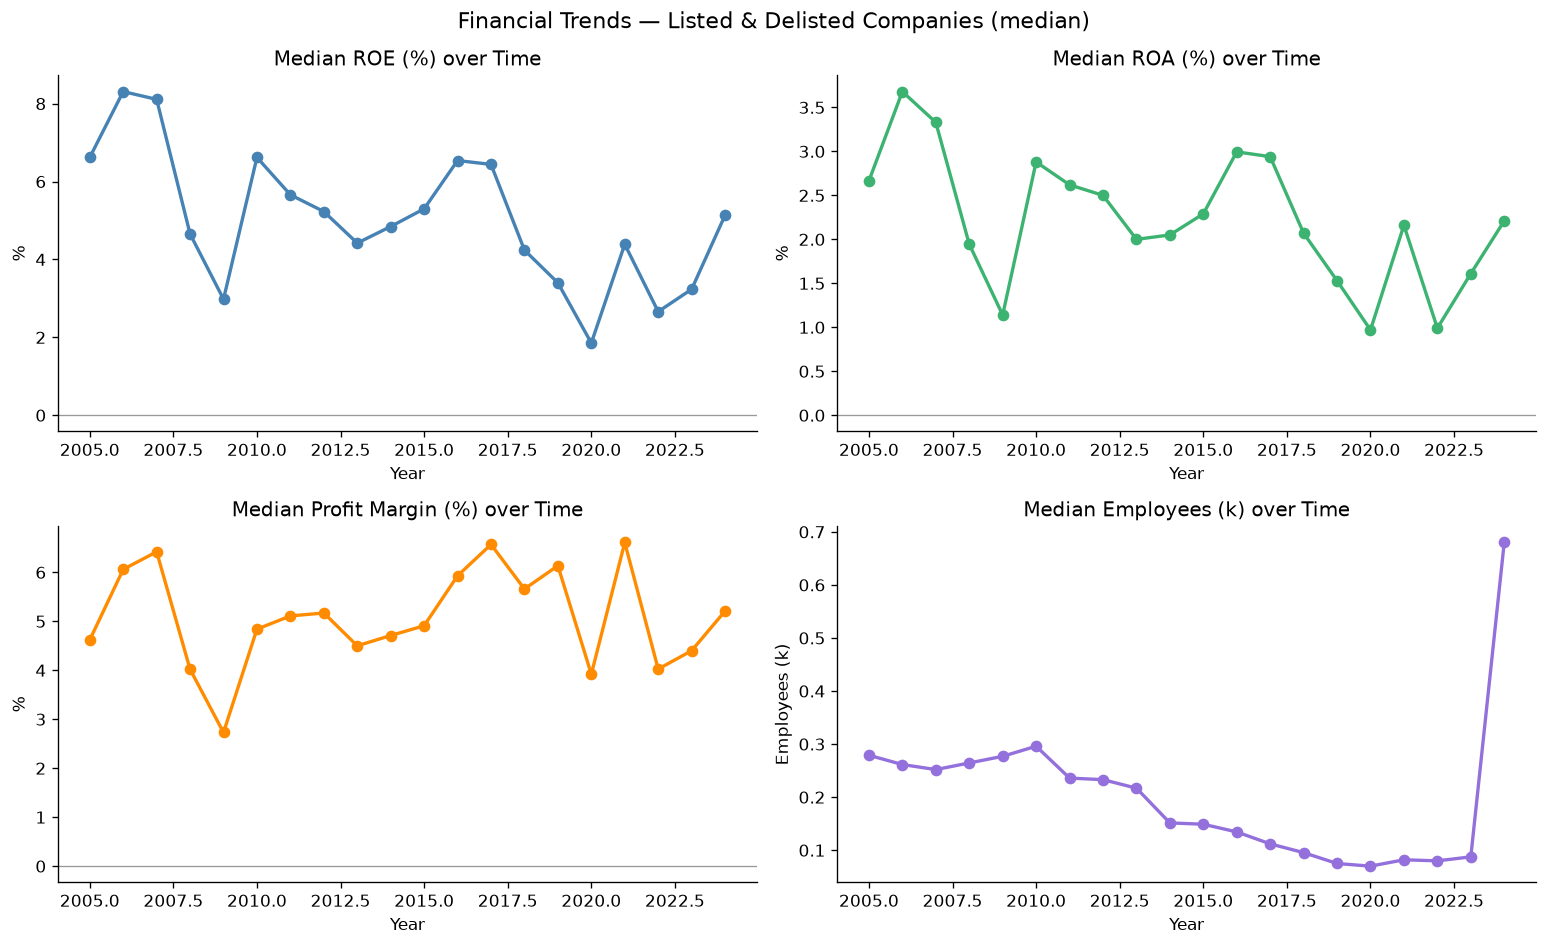

In [56]:
yt = listed.copy()
# Deduplicate to one row per company-year
yt = yt.drop_duplicates(subset=["bvdid","CLOSDATE_year"])
yearly = yt.groupby("CLOSDATE_year")[["ROE","ROA","PRMA","EMPL"]].median()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(yearly.index, yearly["ROE"], marker="o", color="steelblue", linewidth=2)
axes[0,0].axhline(0, color="black", linewidth=0.8, alpha=0.4)
axes[0,0].set_title("Median ROE (%) over Time")
axes[0,0].set_ylabel("%")

axes[0,1].plot(yearly.index, yearly["ROA"], marker="o", color="mediumseagreen", linewidth=2)
axes[0,1].axhline(0, color="black", linewidth=0.8, alpha=0.4)
axes[0,1].set_title("Median ROA (%) over Time")
axes[0,1].set_ylabel("%")

axes[1,0].plot(yearly.index, yearly["PRMA"], marker="o", color="darkorange", linewidth=2)
axes[1,0].axhline(0, color="black", linewidth=0.8, alpha=0.4)
axes[1,0].set_title("Median Profit Margin (%) over Time")
axes[1,0].set_ylabel("%")

axes[1,1].plot(yearly.index, yearly["EMPL"]/1000, marker="o", color="mediumpurple", linewidth=2)
axes[1,1].set_title("Median Employees (k) over Time")
axes[1,1].set_ylabel("Employees (k)")

for ax in axes.flat:
    ax.set_xlabel("Year")

plt.suptitle("Financial Trends — Listed & Delisted Companies (median)", fontsize=13)
plt.tight_layout()
plt.show()


## 12. Column Inventory

In [57]:
# Group the 286 columns
groups = {
    "Identifiers": ["bvdid","SD_ISIN","NAME_INTERNAT","NAME_NATIVE","lei_LEI","SD_TICKER"],
    "Filing metadata": ["CLOSDATE_year","CONSCODE","FILING_TYPE","NR_MONTHS","AUDSTATUS",
                        "ACCPRACTICE","ORIG_UNITS","ORIG_CURRENCY","EXCHRATE"],
    "Balance sheet": ["FIAS","IFAS","TFAS","CUAS","STOK","DEBT","CASH","TOAS","SHFD",
                      "CAPI","NCLI","LTDB","CULI","LOAN","CRED","TSHF","WKCA"],
    "P&L": ["TURN","OPRE","COST","GROS","OOPE","OPPL","PLBT","TAXA","PL","MATE",
            "STAF","DEPR","INTE","RD","CF","EBTA"],
    "Ratios": ["ROE","ROCE","ROA","PRMA","GRMA","ETMA","EBMA","CURR","SOLR","GEAR"],
    "Company info": ["CATEGORY_OF_COMPANY","LISTED","MAINEXCH","LEGALFRM","DATEINC",
                     "IPO_DATE","DELISTED_DATE","DELISTED_COMMENT"],
    "Location": ["NUTS1","NUTS2","NUTS3","CITY_NATIVE","POSTCODE","LATITUDE","LONGITUDE"],
    "Cashflow tables": [c for c in df.columns if c.startswith("O") and len(c)==4],
    "Investment/financing CF": [c for c in df.columns if c.startswith(("I","F","S")) and len(c)==4],
    "Unknown _315xxx": [c for c in df.columns if c.startswith("_315")],
}

for group, cols in groups.items():
    existing = [c for c in cols if c in df.columns]
    print(f"{group}: {len(existing)} cols")
    print(f"  {existing[:10]}{"..." if len(existing)>10 else ""}")
    print()


Identifiers: 6 cols
  ['bvdid', 'SD_ISIN', 'NAME_INTERNAT', 'NAME_NATIVE', 'lei_LEI', 'SD_TICKER']

Filing metadata: 9 cols
  ['CLOSDATE_year', 'CONSCODE', 'FILING_TYPE', 'NR_MONTHS', 'AUDSTATUS', 'ACCPRACTICE', 'ORIG_UNITS', 'ORIG_CURRENCY', 'EXCHRATE']

Balance sheet: 17 cols
  ['FIAS', 'IFAS', 'TFAS', 'CUAS', 'STOK', 'DEBT', 'CASH', 'TOAS', 'SHFD', 'CAPI']...

P&L: 16 cols
  ['TURN', 'OPRE', 'COST', 'GROS', 'OOPE', 'OPPL', 'PLBT', 'TAXA', 'PL', 'MATE']...

Ratios: 10 cols
  ['ROE', 'ROCE', 'ROA', 'PRMA', 'GRMA', 'ETMA', 'EBMA', 'CURR', 'SOLR', 'GEAR']

Company info: 8 cols
  ['CATEGORY_OF_COMPANY', 'LISTED', 'MAINEXCH', 'LEGALFRM', 'DATEINC', 'IPO_DATE', 'DELISTED_DATE', 'DELISTED_COMMENT']

Location: 7 cols
  ['NUTS1', 'NUTS2', 'NUTS3', 'CITY_NATIVE', 'POSTCODE', 'LATITUDE', 'LONGITUDE']

Cashflow tables: 34 cols
  ['OFAS', 'OCAS', 'OSFD', 'ONCL', 'OCLI', 'OPRE', 'OOPE', 'OPPL', 'ONET', 'ODPL']...

Investment/financing CF: 67 cols
  ['FIAS', 'IFAS', 'STOK', 'SHFD', 'FIRE', 'FIEX', 

## 13. Delisting — When Did Companies Leave?

Delisted companies: 661



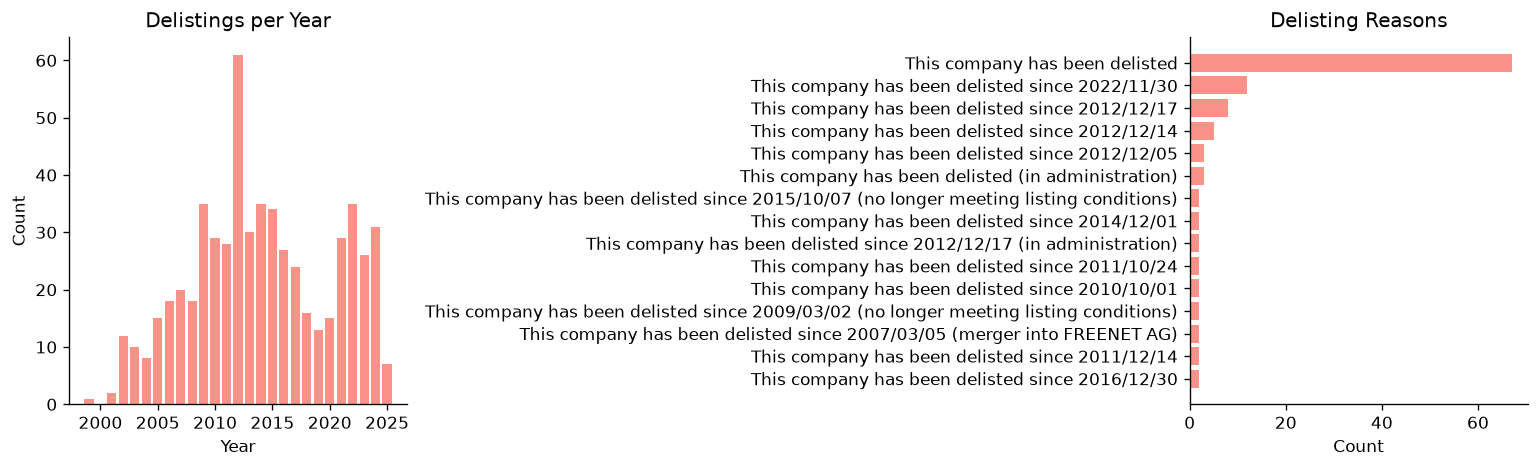

Top delisting reasons:
DELISTED_COMMENT
This company has been delisted                                                            67
This company has been delisted since 2022/11/30                                           12
This company has been delisted since 2012/12/17                                            8
This company has been delisted since 2012/12/14                                            5
This company has been delisted since 2012/12/05                                            3
This company has been delisted (in administration)                                         3
This company has been delisted since 2015/10/07 (no longer meeting listing conditions)     2
This company has been delisted since 2014/12/01                                            2
This company has been delisted since 2012/12/17 (in administration)                        2
This company has been delisted since 2011/10/24                                            2


In [58]:
delisted = df[df["LISTED"]=="Delisted"].drop_duplicates("bvdid").copy()
print(f"Delisted companies: {len(delisted)}")
print()

# Year of delisting
delisted["delist_year"] = pd.to_numeric(
    delisted["DELISTED_DATE_year"], errors="coerce"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

delist_by_year = delisted["delist_year"].dropna().astype(int).value_counts().sort_index()
axes[0].bar(delist_by_year.index, delist_by_year.values, color="salmon", alpha=0.85)
axes[0].set_title("Delistings per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

# Delisting reason — drop NaN before plotting
reason = delisted["DELISTED_COMMENT"].value_counts(dropna=True).head(15)
axes[1].barh(reason.index, reason.values, color="salmon", alpha=0.85)
axes[1].set_title("Delisting Reasons")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Top delisting reasons:")
print(delisted["DELISTED_COMMENT"].value_counts(dropna=False).head(10).to_string())


## 14. Key Findings Summary

| Aspect | Finding |
|---|---|
| **Scale** | 671,626 rows × 286 columns; 77,188 unique companies |
| **Public companies** | 655 currently listed, 661 delisted (~1,316 total) |
| **Universe** | German companies, almost all EUR; mostly Frankfurt-listed AGs and SEs |
| **Consolidation** | Mostly U1 (unconsolidated subsidiaries); C2 (consolidated) only ~74k rows |
| **Units** | 93% in 'thousands', some in 'millions'/'units' — normalize before comparing |
| **Coverage** | Listed co's: TOAS/SHFD ~100%, most financials 86–96%; RD ~55% |
| **Size (listed)** | Extremely skewed — use log scale; ranges from tiny SMEs to VW (€337B revenue) |
| **Profitability (listed)** | Median ROA ~1%, ROE ~2% — low medians reflect many small unprofitable co's |
| **Regions** | Bayern, NRW, and Baden-Württemberg dominate; Munich and Frankfurt top cities |
| **vs merged file** | The merged longitudinal file (157 DAX/MDAX cos) is a focused subset; this file covers the broader German public market |

**Key structural note:** Most rows (501k+) are U1 (unconsolidated individual entities), not group-level accounts.  
For financial analysis of corporate groups, **filter to `CONSCODE == 'C2'`** to get consolidated statements.

## 15. Spotlight: Allianz

In [59]:
# Search by name and ISIN
allianz_mask = (
    df["NAME_INTERNAT"].str.contains("Allianz", case=False, na=False) |
    df["NAME_NATIVE"].str.contains("Allianz", case=False, na=False) |
    df["SD_ISIN"].str.startswith("DE0008404005", na=False)  # Allianz SE ISIN
)
allianz = df[allianz_mask].copy()

print(f"Rows matching 'Allianz': {len(allianz)}")
print(f"Unique bvdids: {allianz['bvdid'].nunique()}")
print()

# Show all distinct entities found
entities = allianz.drop_duplicates("bvdid")[
    ["bvdid","NAME_INTERNAT","NAME_NATIVE","SD_ISIN","LISTED","CONSCODE","LEGALFRM","CITY_NATIVE"]
]
pd.set_option("display.max_colwidth", 50)
print("=== ALLIANZ ENTITIES IN ORBIS ===")
print(entities.to_string(index=False))


Rows matching 'Allianz': 402
Unique bvdids: 56

=== ALLIANZ ENTITIES IN ORBIS ===
       bvdid                                                NAME_INTERNAT                                                 NAME_NATIVE SD_ISIN   LISTED CONSCODE                                                LEGALFRM        CITY_NATIVE
DE2051130363                         FutterAllianz Nordwest GmbH & Co. KG                        FutterAllianz Nordwest GmbH & Co. KG     NaN Unlisted       U1 Limited liability company & partnership - GmbH & Co. KG      Schneiderkrug
DE2230219598            Allianz Renewable Energy Subholding GmbH & Co. KG           Allianz Renewable Energy Subholding GmbH & Co. KG     NaN Unlisted       U1 Limited liability company & partnership - GmbH & Co. KG          Sehestedt
DE3490009532                                           RinderAllianz GmbH                                          RinderAllianz GmbH     NaN Unlisted       U1                        Limited liability company - Gm

Consolidated (C2) Allianz rows: 19
Year range: 2012 – 2020

=== KEY FINANCIALS (latest year) ===
  Total Assets: 722.1 Bn EUR
  Revenue: 2504.9 Bn EUR
  Equity: 269.4 Bn EUR
  Staff Costs: 16.4 Bn EUR
  Net Profit: -6.6 Bn EUR
  ROE: -2.4%  |  ROA: -0.9%  |  Profit margin: 4.2%
  Employees: 169



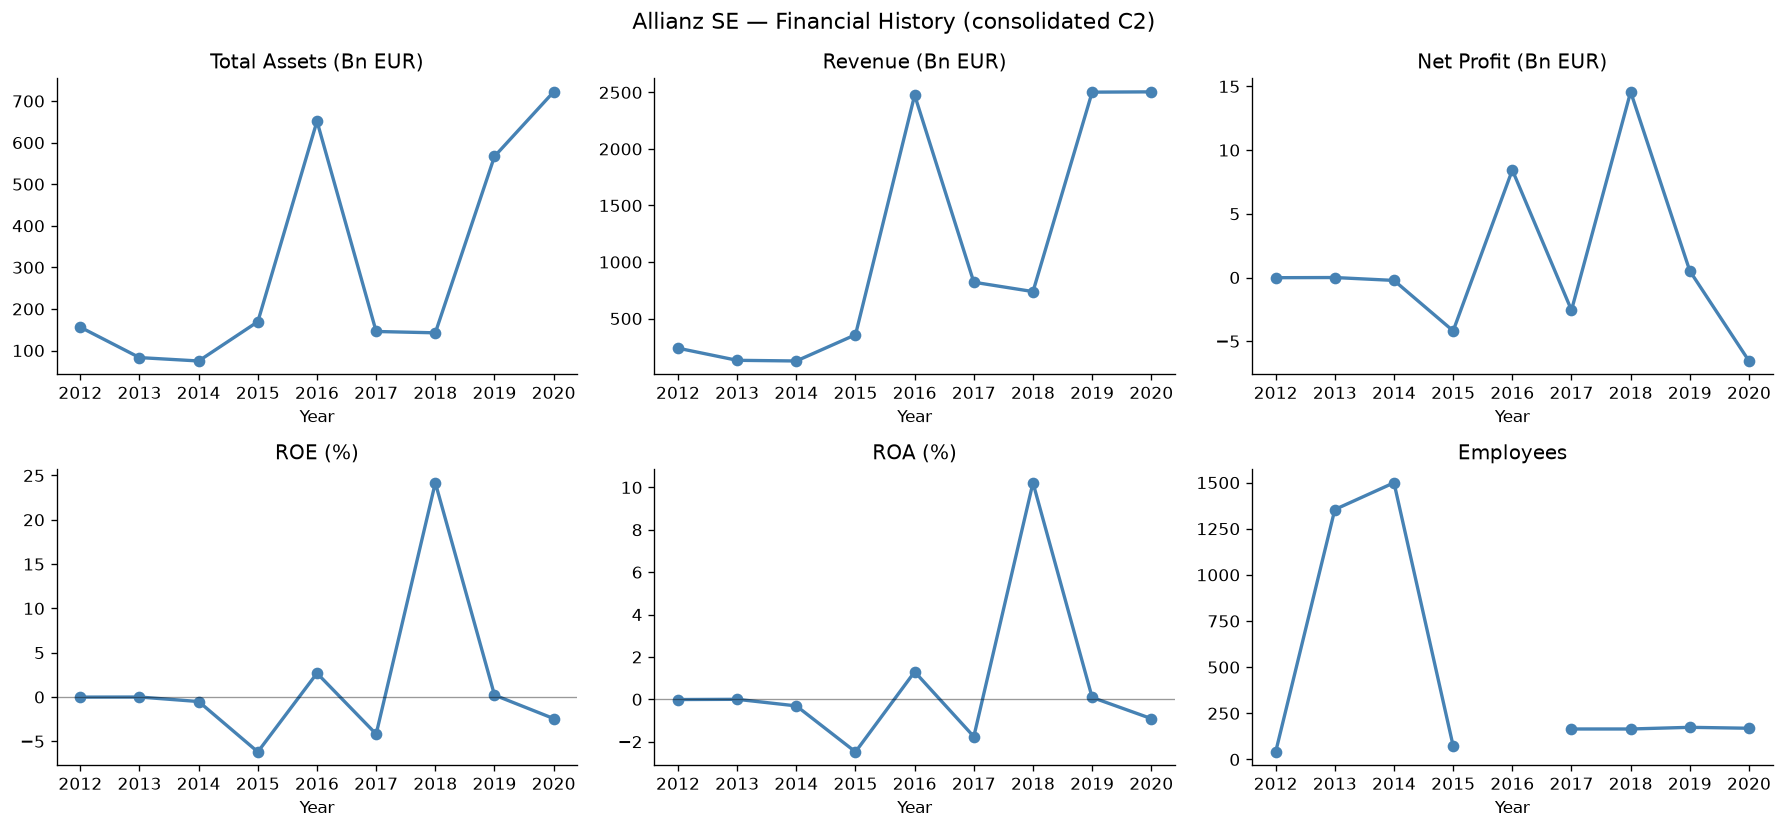

In [60]:
# Focus on the main Allianz SE entity (C2 = consolidated group)
allianz_se = allianz[allianz["CONSCODE"] == "C2"].sort_values("CLOSDATE_year")

if len(allianz_se) == 0:
    print("No C2 rows found — showing all rows for largest entity by row count")
    top_bvd = allianz["bvdid"].value_counts().index[0]
    allianz_se = allianz[allianz["bvdid"] == top_bvd].sort_values("CLOSDATE_year")

print(f"Consolidated (C2) Allianz rows: {len(allianz_se)}")
print(f"Year range: {int(allianz_se['CLOSDATE_year'].min())} – {int(allianz_se['CLOSDATE_year'].max())}")
print()

UNIT_MAP = {"thousands": 1e3, "millions": 1e6, "billions": 1e9, "units": 1.0}
allianz_se = allianz_se.drop_duplicates("CLOSDATE_year")

for col in ["TOAS","TURN","SHFD","STAF","PL"]:
    allianz_se[f"{col}_eur"] = allianz_se[col] * allianz_se["ORIG_UNITS"].map(UNIT_MAP).fillna(1e3)

print("=== KEY FINANCIALS (latest year) ===")
latest = allianz_se.iloc[-1]
for col, label in [("TOAS_eur","Total Assets"), ("TURN_eur","Revenue"), ("SHFD_eur","Equity"),
                   ("STAF_eur","Staff Costs"), ("PL_eur","Net Profit")]:
    val = latest[col]
    print(f"  {label}: {val/1e9:.1f} Bn EUR" if pd.notna(val) else f"  {label}: N/A")
print(f"  ROE: {latest['ROE']:.1f}%  |  ROA: {latest['ROA']:.1f}%  |  Profit margin: {latest['PRMA']:.1f}%")
print(f"  Employees: {int(latest['EMPL']):,}" if pd.notna(latest['EMPL']) else "  Employees: N/A")
print()

# Plot time series
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for ax, col, label, divisor in [
    (axes[0,0], "TOAS_eur", "Total Assets (Bn EUR)", 1e9),
    (axes[0,1], "TURN_eur", "Revenue (Bn EUR)", 1e9),
    (axes[0,2], "PL_eur",   "Net Profit (Bn EUR)", 1e9),
    (axes[1,0], "ROE",      "ROE (%)", 1),
    (axes[1,1], "ROA",      "ROA (%)", 1),
    (axes[1,2], "EMPL",     "Employees", 1),
]:
    col_data = allianz_se[col] / divisor if divisor != 1 else allianz_se[col]
    ax.plot(allianz_se["CLOSDATE_year"], col_data, marker="o", linewidth=2, color="steelblue")
    ax.set_title(label)
    ax.set_xlabel("Year")
    if col in ["ROE","ROA"]:
        ax.axhline(0, color="black", linewidth=0.8, alpha=0.4)

plt.suptitle("Allianz SE — Financial History (consolidated C2)", fontsize=13)
plt.tight_layout()
plt.show()


## 16. Multi-Company Spotlight

In [61]:
COMPANIES = {
    "DE0005408116": "Aareal Bank AG",
    "DE0008404005": "Allianz SE",
    "LU1673108939": "Aroundtown S.A.",
    "LU1704650164": "Befesa SA",
    "DE000CLS1001": "Celesio AG",
    "DE000CBK1001": "Commerzbank AG",
    "DE0008019001": "Deutsche Pfandbriefbank AG",
    "DE0005140008": "Deutsche Bank AG",
    "DE0008001009": "Deutsche Postbank AG",
    "NL0000235190": "Airbus Group SE",
    "DE0005790406": "Fuchs Petrolub SE",
    "LU0269583422": "GAGFAH AG",
    "DE0003304101": "Gerry Weber International AG",
    "LU0775917882": "Grand City Properties S.A.",
    "DE000A161N30": "Grenke AG",
    "DE0008402215": "Hannover Rück SE",
    "DE0006048408": "Henkel AG & Co. KGaA",
    "DE0008027707": "Hypo Real Estate Holding AG",
    "DE0008063306": "IKB Deutsche Industriebank AG",
    "DE0006569908": "MLP AG",
    "DE0008430026": "Munich Re AG",
    "NL0012169213": "Qiagen N.V.",
    "LU0061462528": "RTL Group SA",
    "DE0007165607": "Sartorius AG",
    "NL0012044747": "Shop Apotheke",
    "NL0011375019": "Steinhoff International Holdings N.V.",
    "DE000TUAG000": "TUI AG",
    "DE000TLX1005": "Talanx AG",
    "DE000UNSE018": "Uniper SE",
}

UNIT_MAP = {"thousands": 1e3, "millions": 1e6, "billions": 1e9, "units": 1.0}

def get_company_data(isin):
    """Return C2-consolidated rows for an ISIN, deduplicated by year."""
    rows = df[df["SD_ISIN"].str.strip() == isin].copy()
    c2 = rows[rows["CONSCODE"] == "C2"]
    if len(c2) == 0:
        c2 = rows
    c2 = c2.sort_values("CLOSDATE_year").drop_duplicates("CLOSDATE_year")
    mult = c2["ORIG_UNITS"].map(UNIT_MAP).fillna(1e3)
    for col in ["TOAS","TURN","SHFD","PL","STAF","RD"]:
        c2[f"{col}_eur"] = c2[col] * mult
    return c2

# Unique company snapshot for name searches
snap = df.drop_duplicates("bvdid")[["bvdid","SD_ISIN","NAME_INTERNAT","NAME_NATIVE","LISTED","CONSCODE"]].copy()
known_isins = set(COMPANIES.keys())

print("=" * 90)
print(f"{'ISIN':<16}  {'Target name':<42}  {'Found':<6}  {'Related entities with different ISIN'}")
print("=" * 90)

for isin, name in COMPANIES.items():
    n_rows = (df["SD_ISIN"].str.strip() == isin).sum()
    found = "YES" if n_rows > 0 else "NO "

    # Extract a short keyword from the name (first meaningful word)
    keyword = name.split()[0]
    if keyword.lower() in ("the","de","du","le","la","nr","ag","se","nv","sa"):
        keyword = name.split()[1]

    # Name-based search: similar names but DIFFERENT isin
    name_hits = snap[
        (snap["NAME_INTERNAT"].str.contains(keyword, case=False, na=False) |
         snap["NAME_NATIVE"].str.contains(keyword, case=False, na=False)) &
        (snap["SD_ISIN"].str.strip() != isin) &
        (~snap["SD_ISIN"].str.strip().isin(known_isins))
    ][["SD_ISIN","NAME_INTERNAT","LISTED"]].drop_duplicates("SD_ISIN")

    related = "; ".join(
        f"{r['SD_ISIN']} {r['NAME_INTERNAT']} [{r['LISTED']}]"
        for _, r in name_hits.iterrows()
    ) if len(name_hits) else "-"

    print(f"{isin:<16}  {name:<42}  {found:<6}  {related}")


ISIN              Target name                                 Found   Related entities with different ISIN
DE0005408116      Aareal Bank AG                              NO      nan Aareal Finanz und IT Beteiligungen GmbH [Unlisted]
DE0008404005      Allianz SE                                  NO      nan FutterAllianz Nordwest GmbH & Co. KG [Unlisted]
LU1673108939      Aroundtown S.A.                             NO      -
LU1704650164      Befesa SA                                   NO      nan Befesa Salzschlacke GmbH [Unlisted]
DE000CLS1001      Celesio AG                                  NO      -
DE000CBK1001      Commerzbank AG                              NO      nan Commerzbank Immobilien- u. Vermoegensverwaltungsgesellschaft mbH [Unlisted]
DE0008019001      Deutsche Pfandbriefbank AG                  NO      DE0005508006 Deutscher Eisenhandel Aktiengesellschaft [Delisted]; nan KPMG Deutsche Treuhand- Gesellschaft Aktienges. *** g e l oe s c h t  *** [Unlisted]; DE0005533400 Deu

In [62]:
# Latest-year financial summary table for all companies
rows = []
for isin, name in COMPANIES.items():
    data = get_company_data(isin)
    if len(data) == 0:
        rows.append({"Company": name, "ISIN": isin})
        continue
    latest = data.iloc[-1]
    rows.append({
        "Company":        name,
        "ISIN":           isin,
        "Last Year":      int(latest["CLOSDATE_year"]),
        "Listed":         latest["LISTED"],
        "Revenue (Bn)":   round(latest["TURN_eur"] / 1e9, 1) if pd.notna(latest["TURN_eur"]) else None,
        "Assets (Bn)":    round(latest["TOAS_eur"] / 1e9, 1) if pd.notna(latest["TOAS_eur"]) else None,
        "Net Profit (Bn)":round(latest["PL_eur"]   / 1e9, 2) if pd.notna(latest["PL_eur"])   else None,
        "ROE (%)":        round(latest["ROE"],  1) if pd.notna(latest["ROE"])  else None,
        "ROA (%)":        round(latest["ROA"],  1) if pd.notna(latest["ROA"])  else None,
        "PRMA (%)":       round(latest["PRMA"], 1) if pd.notna(latest["PRMA"]) else None,
        "Employees":      int(latest["EMPL"]) if pd.notna(latest["EMPL"]) else None,
        "Years":          len(data),
    })

summary = pd.DataFrame(rows).set_index("Company")
pd.set_option("display.max_colwidth", 45)
pd.set_option("display.max_rows", 50)
summary


,ISIN,Last Year,Listed,Revenue (Bn),Assets (Bn),Net Profit (Bn),ROE (%),ROA (%),PRMA (%),Employees,Years
Company,,,,,,,,,,,
Aareal Bank AG,DE0005408116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Allianz SE,DE0008404005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aroundtown S.A.,LU1673108939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Befesa SA,LU1704650164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Celesio AG,DE000CLS1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Commerzbank AG,DE000CBK1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Deutsche Pfandbriefbank AG,DE0008019001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Deutsche Bank AG,DE0005140008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Deutsche Postbank AG,DE0008001009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
# Deep search for Deutsche Bank
db_mask = (
    df["NAME_INTERNAT"].str.contains("Deutsche Bank", case=False, na=False) |
    df["NAME_NATIVE"].str.contains("Deutsche Bank", case=False, na=False) |
    df["SD_ISIN"].str.strip().str.startswith("DE0005140008", na=False)
)
db_all = df[db_mask].copy()

print(f"Rows matching 'Deutsche Bank': {len(db_all)}")
print(f"Unique bvdids: {db_all['bvdid'].nunique()}")
print()

entities = (
    db_all.drop_duplicates("bvdid")
    [["bvdid","SD_ISIN","NAME_INTERNAT","NAME_NATIVE","LISTED","CONSCODE","LEGALFRM","CITY_NATIVE","CLOSDATE_year"]]
    .sort_values(["LISTED","NAME_INTERNAT"])
)
pd.set_option("display.max_colwidth", 55)
pd.set_option("display.max_rows", 100)
print("=== ALL DEUTSCHE BANK ENTITIES IN ORBIS ===")
print(entities.to_string(index=False))


Rows matching 'Deutsche Bank': 10
Unique bvdids: 1

=== ALL DEUTSCHE BANK ENTITIES IN ORBIS ===
       bvdid SD_ISIN                 NAME_INTERNAT                   NAME_NATIVE   LISTED CONSCODE                         LEGALFRM CITY_NATIVE  CLOSDATE_year
DE2170008841     NaN Deutsche Bank Immobilien GmbH Deutsche Bank Immobilien GmbH Unlisted       U1 Limited liability company - GmbH      Hameln           2023


In [64]:
# For each Deutsche Bank entity: how many years of data, which consolidation codes, year range
db_snap = db_all.groupby("bvdid").agg(
    name=("NAME_INTERNAT", "first"),
    isin=("SD_ISIN", "first"),
    listed=("LISTED", "first"),
    concodes=("CONSCODE", lambda x: ", ".join(sorted(x.dropna().unique()))),
    year_min=("CLOSDATE_year", "min"),
    year_max=("CLOSDATE_year", "max"),
    n_years=("CLOSDATE_year", "nunique"),
    has_C2=("CONSCODE", lambda x: "C2" in x.values),
).reset_index().sort_values(["listed","n_years"], ascending=[True, False])

print(db_snap.to_string(index=False))


       bvdid                          name isin   listed concodes  year_min  year_max  n_years  has_C2
DE2170008841 Deutsche Bank Immobilien GmbH  NaN Unlisted       U1      2014      2023       10   False
